# Executable Project Booklet
## Monthly Property-Crime Forecasting in Comas, Metropolitan Lima

**Researcher:** Enrique Lee Huamani Uriarte  
**Official source:** Ministry of the Interior / SIDPOL  
**Period:** January 2018–May 2026  
**Geographic scope:** Comas District, UBIGEO 150110

This notebook documents and executes the complete real-data process: source verification, filtering, monthly aggregation, exploratory analysis, leakage-controlled feature engineering, temporal splitting, model training, evaluation, forecasts, and interpretation.

## 1. Research objective

The objective is to determine whether machine-learning models using lagged, seasonal, and trend features can improve next-month prediction of aggregated theft and robbery reports in Comas compared with transparent historical baselines.

In [1]:
from pathlib import Path
import hashlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name != '05_pipeline':
    ROOT = ROOT / '05_pipeline'
sys.path.insert(0, str(ROOT / 'src'))
from train import (
    DATA_PATH, TEST_START, build_features, load_comas_monthly_data, run_training
)
pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')
print('Pipeline root:', ROOT.resolve())
print('Official data file:', DATA_PATH.name)

Pipeline root: C:\Users\enriq\Downloads\PROYECTO  DOCTORADO\repo_review\05_pipeline
Official data file: sidpol_police_reports_2018_2026.csv


## 2. Official data provenance

The dataset was published by Peru's Ministry of the Interior on the National Open Data Platform. It originates from the Police Complaints Information System (SIDPOL) and is distributed under the Open Data Commons Attribution License. It is aggregated by time, geography, category, and count and contains no names, addresses, or individual coordinates.

In [2]:
sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
manifest = pd.DataFrame([{
    'publisher': 'Ministry of the Interior of Peru',
    'system': 'SIDPOL',
    'coverage': 'January 2018–May 2026',
    'file_bytes': DATA_PATH.stat().st_size,
    'sha256': sha256,
    'source': 'https://www.datosabiertos.gob.pe/dataset/denuncias-policiales-1'
}])
display(manifest)

,publisher,system,coverage,file_bytes,sha256,source
0,Ministry of the Interior of Peru,SIDPOL,January 2018–May 2026,26896357,CDC6D3D32A37A00FF7F2F1D15D65512FEC3A36A0291BB6...,https://www.datosabiertos.gob.pe/dataset/denun...


## 3. Raw data inspection

The original national table is loaded without altering its published values. The geographic code is read as text to preserve all six digits.

In [3]:
raw = pd.read_csv(DATA_PATH, dtype={'UBIGEO_HECHO': str})
print(f'National rows: {len(raw):,}')
print('Columns:', list(raw.columns))
display(raw.head(8))

National rows: 361,792
Columns: ['ANIO', 'MES', 'DPTO_HECHO_NEW', 'PROV_HECHO', 'DIST_HECHO', 'UBIGEO_HECHO', 'P_MODALIDADES', 'cantidad']


,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Otros,4
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Violencia contra la mujer e integrantes,3
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Estafa,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Hurto,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Otros,52
5,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Robo,5
6,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Violencia contra la mujer e integrantes,22
7,2018,1,AMAZONAS,BAGUA,COPALLIN,10203,Otros,4


## 4. Geographic and outcome filtering

Comas is selected through UBIGEO `150110`, not only by district name. This prevents accidental inclusion of the district named Comas in Junín. The analytical outcome includes only `Hurto` and `Robo`.

In [4]:
raw['UBIGEO_HECHO'] = raw['UBIGEO_HECHO'].str.zfill(6)
comas_all = raw[raw['UBIGEO_HECHO'] == '150110'].copy()
category_summary = (comas_all.groupby('P_MODALIDADES', as_index=False)['cantidad']
                    .sum().sort_values('cantidad', ascending=False))
print(f'Comas source rows: {len(comas_all):,}')
print(f'All-category reports: {comas_all.cantidad.sum():,}')
display(category_summary)

Comas source rows: 698
All-category reports: 144,736


,P_MODALIDADES,cantidad
6,Violencia contra la mujer e integrantes,49602
3,Otros,40602
4,Robo,24620
2,Hurto,22934
0,Estafa,3807
1,Extorsión,2807
5,Secuestro,364


## 5. Monthly analytical series

Theft and robbery are pivoted into separate columns, a complete monthly index is constructed, and both categories are added to form the property-crime outcome.

In [5]:
monthly = load_comas_monthly_data()
summary = pd.DataFrame([{
    'monthly_periods': len(monthly),
    'start': monthly.date.min().strftime('%Y-%m'),
    'end': monthly.date.max().strftime('%Y-%m'),
    'theft_reports': int(monthly.theft_reports.sum()),
    'robbery_reports': int(monthly.robbery_reports.sum()),
    'combined_reports': int(monthly.property_crime_reports.sum()),
    'monthly_mean': round(monthly.property_crime_reports.mean(), 2),
}])
display(summary)
display(monthly.head(12))

,monthly_periods,start,end,theft_reports,robbery_reports,combined_reports,monthly_mean
0,101,2018-01,2026-05,22934,24620,47554,470.83


P_MODALIDADES,date,theft_reports,robbery_reports,property_crime_reports
0,2018-01-01,244,193,437
1,2018-02-01,296,257,553
2,2018-03-01,255,279,534
3,2018-04-01,237,272,509
4,2018-05-01,232,281,513
5,2018-06-01,246,338,584
6,2018-07-01,233,282,515
7,2018-08-01,230,306,536
8,2018-09-01,213,261,474
9,2018-10-01,295,298,593


## 6. Exploratory time-series analysis

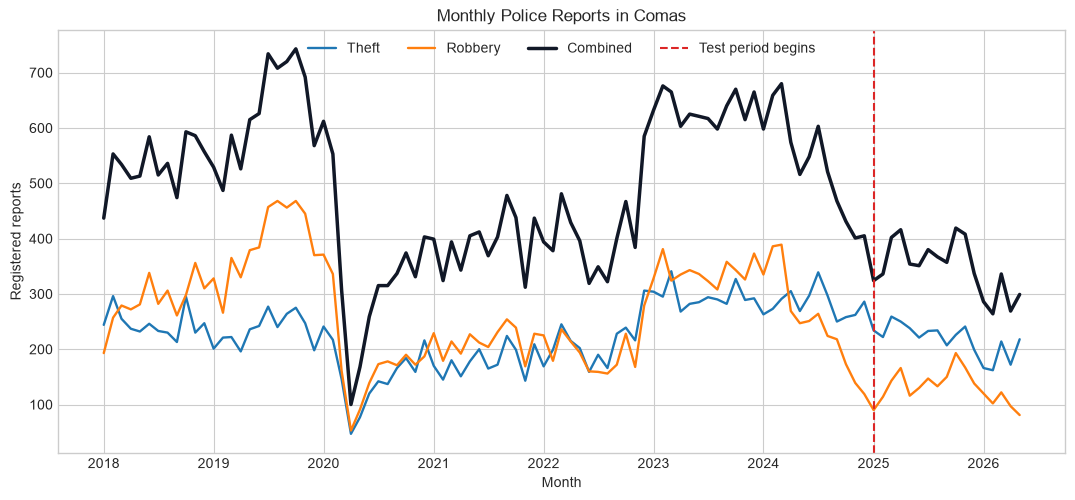

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(monthly.date, monthly.theft_reports, label='Theft', linewidth=1.7)
ax.plot(monthly.date, monthly.robbery_reports, label='Robbery', linewidth=1.7)
ax.plot(monthly.date, monthly.property_crime_reports, label='Combined', color='#111827', linewidth=2.5)
ax.axvline(TEST_START, color='#dc2626', linestyle='--', label='Test period begins')
ax.set(title='Monthly Police Reports in Comas', xlabel='Month', ylabel='Registered reports')
ax.legend(ncol=4)
plt.show()

The series contains a substantial disruption around the COVID-19 period and a lower level toward 2026. This temporal drift makes random train-test splitting inappropriate.

## 7. Leakage-controlled feature engineering

Features include current category counts, lags of 1, 2, 3, 6, and 12 months, shifted rolling means, recent trend, time index, and cyclic month encodings. The target is shifted one month forward.

In [7]:
feature_frame, feature_names = build_features(monthly)
print('Model features:')
print(feature_names)
print(f'Complete modeling rows: {len(feature_frame)}')
display(feature_frame[['date', *feature_names, 'target_next_month']].head(8))

Model features:
['time_index', 'month_sin', 'month_cos', 'property_crime_reports', 'theft_reports', 'robbery_reports', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'recent_trend']
Complete modeling rows: 88


P_MODALIDADES,date,time_index,month_sin,month_cos,property_crime_reports,theft_reports,robbery_reports,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,recent_trend,target_next_month
12,2019-01-01,12,5.000000e-01,8.660254e-01,529,201,328,557.0,586.0,593.0,515.0,437.0,578.666667,543.500000,-36.0,487.0
13,2019-02-01,13,8.660254e-01,5.000000e-01,487,221,266,529.0,557.0,586.0,536.0,553.0,557.333333,545.833333,-57.0,587.0
14,2019-03-01,14,1.000000e+00,6.123234e-17,587,222,365,487.0,529.0,557.0,474.0,534.0,524.333333,537.666667,-70.0,526.0
15,2019-04-01,15,8.660254e-01,-5.000000e-01,526,196,330,587.0,487.0,529.0,593.0,509.0,534.333333,556.500000,58.0,615.0
16,2019-05-01,16,5.000000e-01,-8.660254e-01,615,236,379,526.0,587.0,487.0,586.0,513.0,533.333333,545.333333,39.0,626.0
17,2019-06-01,17,1.224647e-16,-1.000000e+00,626,242,384,615.0,526.0,587.0,557.0,584.0,576.000000,550.166667,28.0,734.0
18,2019-07-01,18,-5.000000e-01,-8.660254e-01,734,277,457,626.0,615.0,526.0,529.0,515.0,589.000000,561.666667,100.0,708.0
19,2019-08-01,19,-8.660254e-01,-5.000000e-01,708,240,468,734.0,626.0,615.0,487.0,536.0,658.333333,595.833333,119.0,720.0


## 8. Temporal validation design

Rows before January 2025 are used for training. Rows from January 2025 onward predict February 2025 through May 2026. Test observations are not used for fitting or standardization.

In [8]:
train = feature_frame[feature_frame.date < TEST_START]
test = feature_frame[feature_frame.date >= TEST_START]
split_summary = pd.DataFrame([
    {'partition': 'Training', 'rows': len(train), 'first_feature_month': train.date.min().strftime('%Y-%m'), 'last_feature_month': train.date.max().strftime('%Y-%m')},
    {'partition': 'Test', 'rows': len(test), 'first_feature_month': test.date.min().strftime('%Y-%m'), 'last_feature_month': test.date.max().strftime('%Y-%m')},
])
display(split_summary)

,partition,rows,first_feature_month,last_feature_month
0,Training,72,2019-01,2024-12
1,Test,16,2025-01,2026-04


## 9. Models trained

Six approaches are evaluated on identical months:

1. Persistence baseline.
2. Twelve-month seasonal-naive baseline.
3. Standardized linear regression.
4. Ridge regression with alpha 10.
5. Random forest with 500 trees.
6. Regularized histogram gradient boosting.

## 10. Execute model training

In [9]:
results, forecasts, metadata, fitted_models = run_training(seed=42)
display(pd.DataFrame([metadata]))
display(results.sort_values('mae').reset_index(drop=True))

,raw_rows,monthly_periods,property_crime_reports,training_rows,test_rows,data_start,data_end
0,698,101,47554,72,16,2018-01,2026-05


,model,seed,mae,rmse,r2,mape_pct
0,persistence_baseline,42,37.187500,44.946496,0.141087,11.049658
1,ridge_regression,42,43.114170,50.711392,-0.093374,13.037476
2,random_forest,42,45.419483,54.977302,-0.285063,14.492375
3,linear_regression,42,47.112091,54.848380,-0.279043,14.378172
4,hist_gradient_boosting,42,56.144351,68.566583,-0.998861,17.877509
5,seasonal_naive_12m,42,143.812500,167.144212,-10.877918,41.138059


## 11. Repeated-seed model comparison

The saved experiment table contains seeds 13, 21, 42, 87, and 100. Mean absolute error is the primary selection metric because it is expressed directly in monthly report counts.

,model,mae_mean,mae_sd,rmse_mean,r2_mean,mape_pct_mean
0,persistence_baseline,37.187500,0.000000,44.946496,0.141087,11.049658
1,ridge_regression,43.114170,0.000000,50.711392,-0.093374,13.037476
2,random_forest,46.987164,1.489738,56.700506,-0.367787,15.002892
3,linear_regression,47.112091,0.000000,54.848380,-0.279043,14.378172
4,hist_gradient_boosting,56.144351,0.000000,68.566583,-0.998861,17.877509
5,seasonal_naive_12m,143.812500,0.000000,167.144212,-10.877918,41.138059


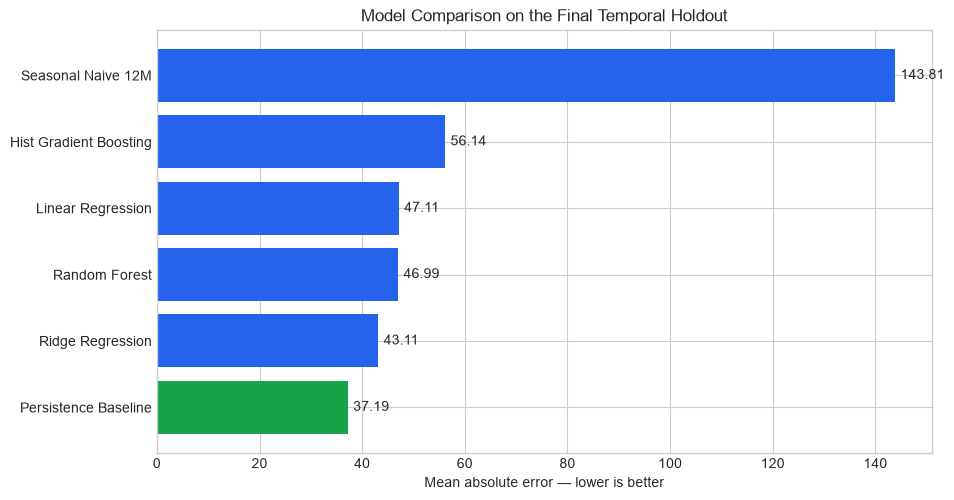

In [10]:
experiments = pd.read_csv(ROOT / 'docs' / 'experiment_results.csv')
comparison = pd.read_csv(ROOT / 'docs' / 'model_comparison.csv')
display(comparison)
ordered = comparison.sort_values('mae_mean')
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#16a34a' if m == 'persistence_baseline' else '#2563eb' for m in ordered.model]
bars = ax.barh(ordered.model.str.replace('_', ' ').str.title(), ordered.mae_mean, color=colors)
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.set(title='Model Comparison on the Final Temporal Holdout', xlabel='Mean absolute error — lower is better')
plt.show()

## 12. Month-level test forecasts

,feature_month,forecast_month,observed,persistence_baseline,seasonal_naive_12m,linear_regression,ridge_regression,random_forest,hist_gradient_boosting
84,2025-01,2025-02,336,324,598.0,308.63,325.36,380.97,358.65
85,2025-02,2025-03,402,336,659.0,335.15,328.73,378.52,385.87
86,2025-03,2025-04,416,402,680.0,382.99,375.30,389.54,394.58
87,2025-04,2025-05,354,416,574.0,412.50,409.52,416.45,410.60
88,2025-05,2025-06,351,354,516.0,373.30,380.04,394.58,423.26
89,2025-06,2025-07,380,351,548.0,397.68,378.61,391.16,407.30
90,2025-07,2025-08,367,380,603.0,405.65,399.51,384.47,401.80
91,2025-08,2025-09,357,367,521.0,387.01,398.73,393.08,435.00
92,2025-09,2025-10,419,357,468.0,404.93,393.73,392.66,416.26
93,2025-10,2025-11,408,419,431.0,466.96,434.39,408.76,420.57


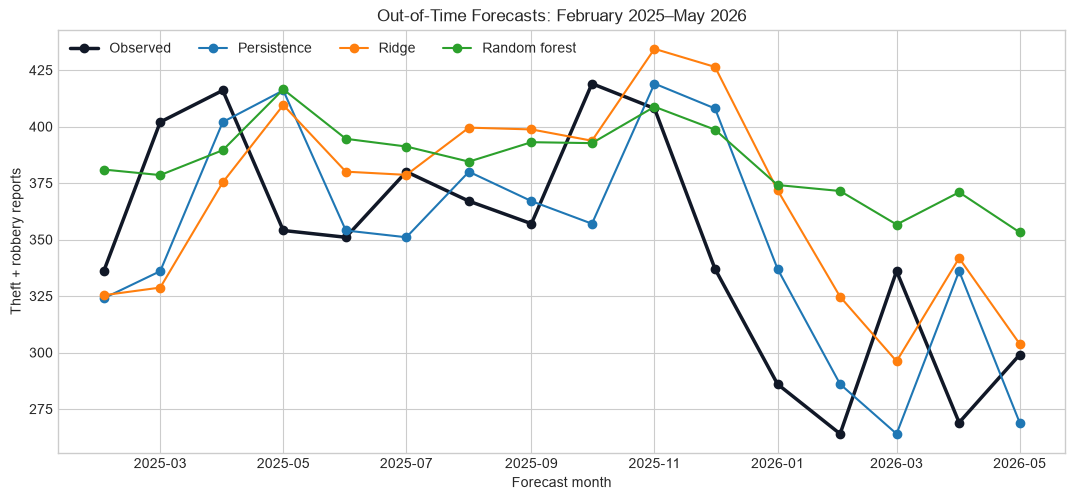

In [11]:
display(forecasts)
plot_data = forecasts.copy()
plot_data['forecast_month'] = pd.to_datetime(plot_data['forecast_month'])
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(plot_data.forecast_month, plot_data.observed, marker='o', linewidth=2.5, color='#111827', label='Observed')
ax.plot(plot_data.forecast_month, plot_data.persistence_baseline, marker='o', label='Persistence')
ax.plot(plot_data.forecast_month, plot_data.ridge_regression, marker='o', label='Ridge')
ax.plot(plot_data.forecast_month, plot_data.random_forest, marker='o', label='Random forest')
ax.set(title='Out-of-Time Forecasts: February 2025–May 2026', xlabel='Forecast month', ylabel='Theft + robbery reports')
ax.legend(ncol=4)
plt.show()

## 13. Interpretation of results

The persistence baseline achieved the best performance: MAE 37.19, RMSE 44.95, R² 0.141, and MAPE 11.05%. Ridge regression was the strongest fitted model but did not improve upon persistence. Random forest remained too high during the early-2026 decline. Negative R² values show that several fitted models performed worse than predicting the test-period mean.

The scientific conclusion is not that machine learning succeeded merely because models were trained. The valid conclusion is that the tested feature set and sample do not justify replacing the simple persistence comparator.

## 14. Limitations and responsible use

- Police reports reflect occurrence, reporting behavior, and recording practices.
- The public file provides district-level aggregates and no intradistrict coordinates.
- The 101-month series is small for high-capacity machine learning.
- COVID-19 and later changes create temporal drift.
- The analysis predicts reports and does not identify causes or intervention effects.
- Results must not be used to profile individuals or label communities as inherently dangerous.

## 15. Final conclusion

This notebook demonstrates a completed and reproducible real-data machine-learning experiment for Comas. It documents the full path from official source data to out-of-time evaluation. The strongest tested method is persistence, establishing a defensible benchmark for future work with richer authorized predictors or finer territorial units.